In [1]:
# improve matplotlib dpi print
%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

/usr/local/lib/python3.11/dist-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
import trieste
import gpflow

/usr/local/lib/python3.11/dist-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
from trieste.objectives import ScaledBranin
from trieste.experimental.plotting import plot_function_plotly
from trieste.space import Box

from trieste.models.gpflow import GaussianProcessRegression

In [5]:
np.random.seed(1793)
tf.random.set_seed(1793)

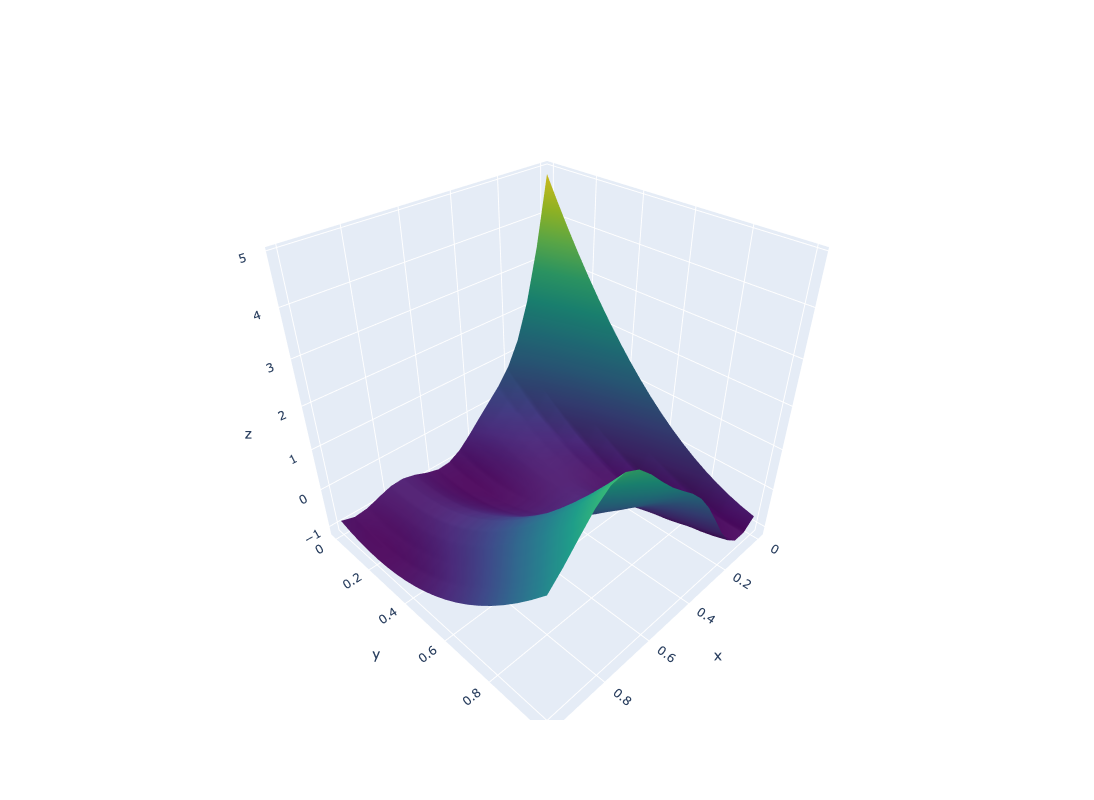

In [6]:
# import included objective function
scaled_branin = ScaledBranin.objective

# predefined search space
search_space = ScaledBranin.search_space  

# define the search space directly
search_space = Box([0, 0], [1, 1])  

# plot the function using trieste built-in plotting
fig = plot_function_plotly(
    scaled_branin,
    search_space.lower,
    search_space.upper,
    grid_density=20,
)
fig.update_layout(height=800, width=1000)
fig.show()

In [7]:
# create a function that observes the objective at certain points
observer = trieste.objectives.utils.mk_observer(scaled_branin)

# sample 5 points using Sobol design
num_initial_points = 5
initial_query_points = search_space.sample_sobol(num_initial_points)
initial_data = observer(initial_query_points)

In [8]:
initial_query_points

<tf.Tensor: shape=(5, 2), dtype=float64, numpy=
array([[0.75563049, 0.81419373],
       [0.50563049, 0.06419373],
       [0.00563049, 0.56419373],
       [0.00758362, 0.06614685],
       [0.50758362, 0.56614685]])>

In [9]:
initial_data

Dataset(query_points=<tf.Tensor: shape=(5, 2), dtype=float64, numpy=
array([[0.75563049, 0.81419373],
       [0.50563049, 0.06419373],
       [0.00563049, 0.56419373],
       [0.00758362, 0.06614685],
       [0.50758362, 0.56614685]])>, observations=<tf.Tensor: shape=(5, 1), dtype=float64, numpy=
array([[ 1.69840912],
       [-0.95799407],
       [ 0.55955954],
       [ 4.01676171],
       [-0.38146871]])>)

In [10]:
initial_data.observations

<tf.Tensor: shape=(5, 1), dtype=float64, numpy=
array([[ 1.69840912],
       [-0.95799407],
       [ 0.55955954],
       [ 4.01676171],
       [-0.38146871]])>

In [11]:
from trieste.models.gpflow import GaussianProcessRegression

def build_model(data):
    variance = tf.math.reduce_variance(data.observations)
    kernel = gpflow.kernels.Matern52(variance=variance, lengthscales=[0.2, 0.2])
    prior_scale = tf.cast(1.0, dtype=tf.float64)
    kernel.variance.prior = tfp.distributions.LogNormal(
        tf.cast(-2.0, dtype=tf.float64), prior_scale
    )
    kernel.lengthscales.prior = tfp.distributions.LogNormal(
        tf.math.log(kernel.lengthscales), prior_scale
    )
    gpr = gpflow.models.GPR(data.astuple(), kernel, noise_variance=1e-5)
    gpflow.set_trainable(gpr.likelihood, False)

    return GaussianProcessRegression(gpr, num_kernel_samples=100)


model = build_model(initial_data)

In [12]:
from trieste.models.gpflow import build_gpr

gpflow_model = build_gpr(initial_data, search_space, likelihood_variance=1e-7)
model = GaussianProcessRegression(gpflow_model, num_kernel_samples=100)

In [13]:
bo = trieste.bayesian_optimizer.BayesianOptimizer(observer, search_space)

num_steps = 15
result = bo.optimize(num_steps, initial_data, model)
dataset = result.try_get_final_dataset()

Optimization completed without errors


In [14]:
query_point, observation, arg_min_idx = result.try_get_optimal_point()

print(f"query point: {query_point}")
print(f"observation: {observation}")

query point: [0.5422248  0.15261826]
observation: [-1.04738646]


Text(0.5, 0, '$x_2$')

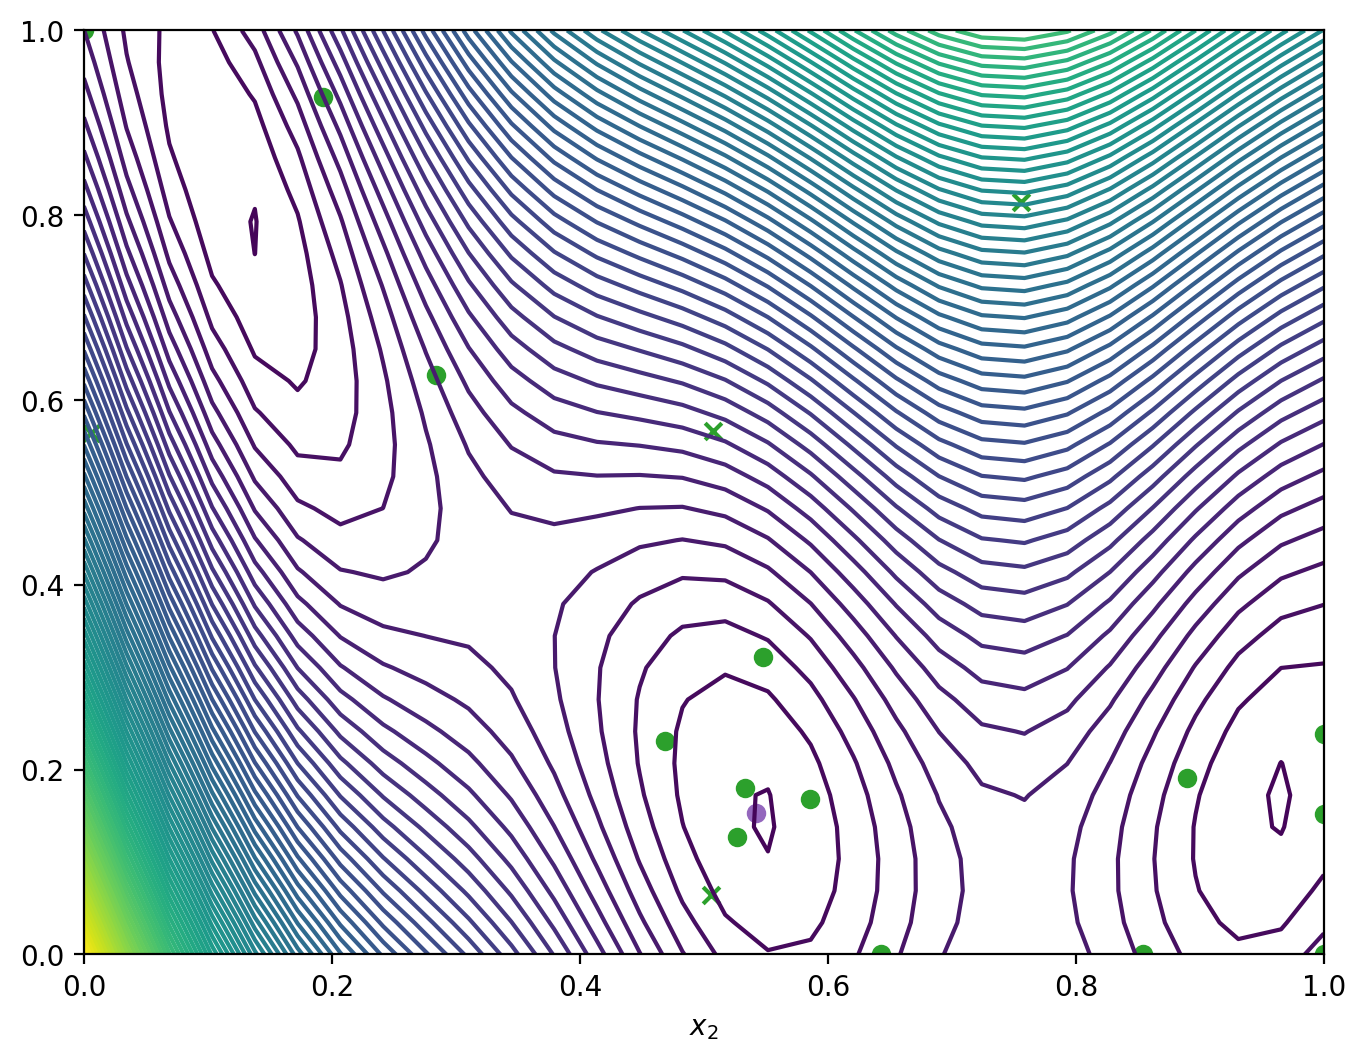

In [15]:
from trieste.experimental.plotting import plot_bo_points, plot_function_2d

query_points = dataset.query_points.numpy()
observations = dataset.observations.numpy()

_, ax = plot_function_2d(
    scaled_branin,
    search_space.lower,
    search_space.upper,
    grid_density=30,
    contour=True,
)
plot_bo_points(query_points, ax[0, 0], num_initial_points, arg_min_idx)
ax[0, 0].set_xlabel(r"$x_1$")
ax[0, 0].set_xlabel(r"$x_2$")

Text(0.5, 0, '# evaluations')

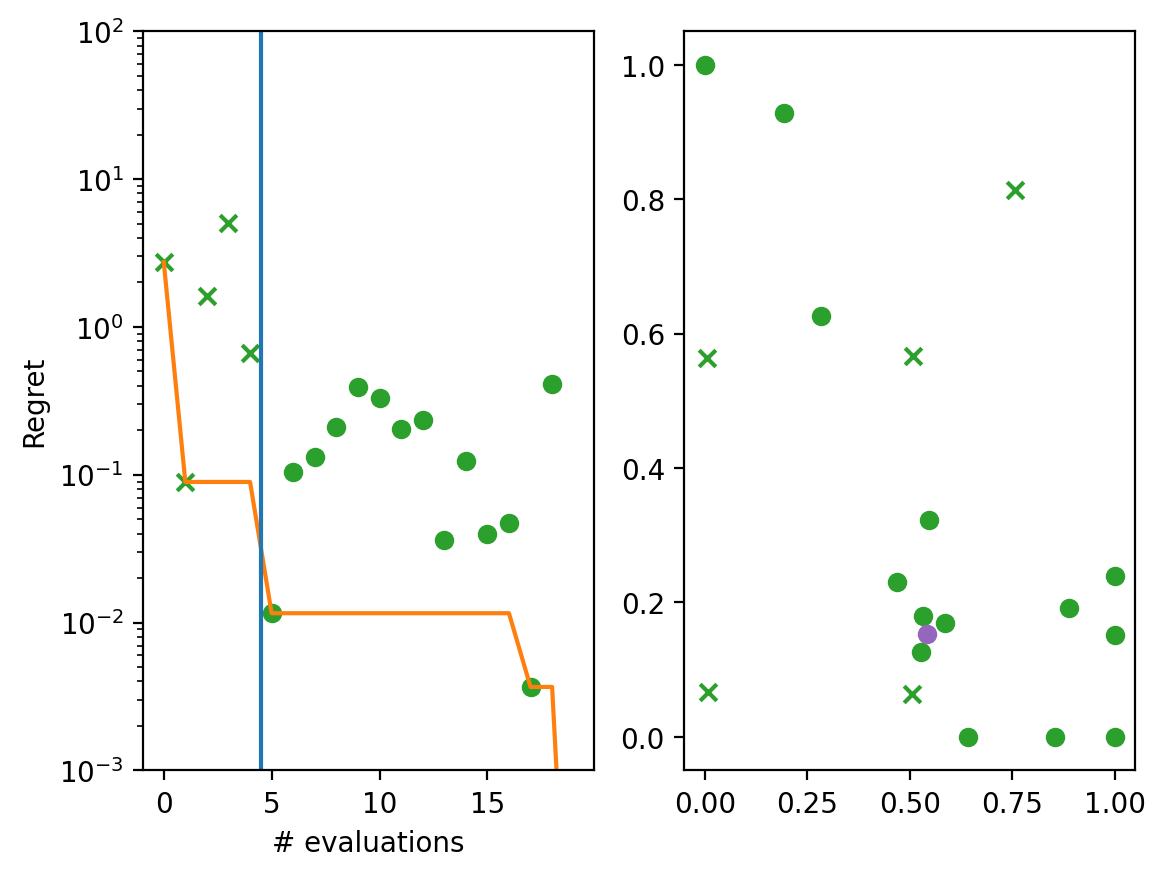

In [16]:
import matplotlib.pyplot as plt
from trieste.experimental.plotting import plot_regret

suboptimality = observations - ScaledBranin.minimum.numpy()
_, ax = plt.subplots(1, 2)
plot_regret(
    suboptimality, ax[0], num_init=num_initial_points, idx_best=arg_min_idx
)
plot_bo_points(
    query_points, ax[1], num_init=num_initial_points, idx_best=arg_min_idx
)

ax[0].set_yscale("log")
ax[0].set_ylabel("Regret")
ax[0].set_ylim(0.001, 100)
ax[0].set_xlabel("# evaluations")